# 02: Classical Baseline, TF-IDF + Linear Models

A non-deep reference point. Nandanwar & Choudhary (2023) report classical and
recurrent baselines below their fine-tuned BERT, which supports the expected
ordering from classical methods to transformers. This notebook establishes the
classical rung so later notebooks can quantify the transformer's added value.

In [1]:
import json
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from wcc.data import PROCESSED_DIR, load_processed
from wcc.metrics import compute_metrics, confusion, plot_confusion_matrix, print_report

train, val, test, label_map = load_processed()
label_names = [k for k, _ in sorted(label_map.items(), key=lambda kv: kv[1])]
RESULTS_DIR = PROCESSED_DIR.parent / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = PROCESSED_DIR.parent.parent / "figures"  # tracked, repo root
FIG_DIR.mkdir(parents=True, exist_ok=True)

## TF-IDF features

Word 1-2 grams, English stop-words removed, sublinear term frequency.

In [2]:
vec = TfidfVectorizer(max_features=50_000, ngram_range=(1, 2), stop_words="english",
                      min_df=3, sublinear_tf=True)
Xtr = vec.fit_transform(train["content"])
Xva = vec.transform(val["content"])
Xte = vec.transform(test["content"])
ytr, yva, yte = train["label"], val["label"], test["label"]
print("TF-IDF matrix:", Xtr.shape)

TF-IDF matrix: (6332, 50000)


## Model selection on the validation split

`class_weight='balanced'` is the linear-model analogue of our weighted loss.

In [3]:
candidates = {
    "LogReg":    LogisticRegression(max_iter=2000, C=10.0, class_weight="balanced"),
    "LinearSVC": LinearSVC(C=1.0, class_weight="balanced"),
}
val_scores = {}
for name, clf in candidates.items():
    clf.fit(Xtr, ytr)
    m = compute_metrics(yva, clf.predict(Xva), label_names)
    val_scores[name] = m["macro_f1"]
    print(f"{name:<10} val macro-F1 = {m['macro_f1']:.4f}  acc = {m['accuracy']:.4f}")

best_name = max(val_scores, key=val_scores.get)
print(f"\nselected: {best_name}")

LogReg     val macro-F1 = 0.4803  acc = 0.5455


LinearSVC  val macro-F1 = 0.4816  acc = 0.5511

selected: LinearSVC


## Final evaluation on the held-out test split

The test set is touched exactly once.

In [4]:
best = candidates[best_name]
test_metrics = compute_metrics(yte, best.predict(Xte), label_names)
print_report(test_metrics, f"TF-IDF + {best_name}: TEST")

result = {"model": f"tfidf_{best_name.lower()}", "val_macro_f1": val_scores[best_name],
          "test_macro_f1": test_metrics["macro_f1"], "test_accuracy": test_metrics["accuracy"]}
(RESULTS_DIR / "baseline.json").write_text(json.dumps(result, indent=2))
result


=== TF-IDF + LinearSVC: TEST ===
  accuracy    : 0.5329
  macro-F1    : 0.4728
  weighted-F1 : 0.5217
  class                           P       R      F1      n
  News_and_Media              0.111   0.048   0.067     63
  Adult                       1.000   0.050   0.095     20
  Arts_and_Entertainment      0.280   0.175   0.215     40
  Career_and_Education        0.280   0.304   0.292     46
  Internet_and_Telecom        0.316   0.308   0.312     78
  Business_and_Industry       0.338   0.305   0.321     82
  Home_and_Garden             0.500   0.267   0.348     15
  Science                     0.390   0.448   0.417     67
  People_and_Society          0.521   0.370   0.433    100
  Recreation_and_Hobbies      0.500   0.395   0.441     38
  Computer_and_Electronics    0.383   0.537   0.447     67
  Shopping                    0.548   0.442   0.489     52
  Travel                      0.512   0.525   0.519     40
  Games                       0.595   0.468   0.524     47
  Pets_and_A

{'model': 'tfidf_linearsvc',
 'val_macro_f1': 0.48162773898944317,
 'test_macro_f1': 0.47277779981442686,
 'test_accuracy': 0.5329308452250274}

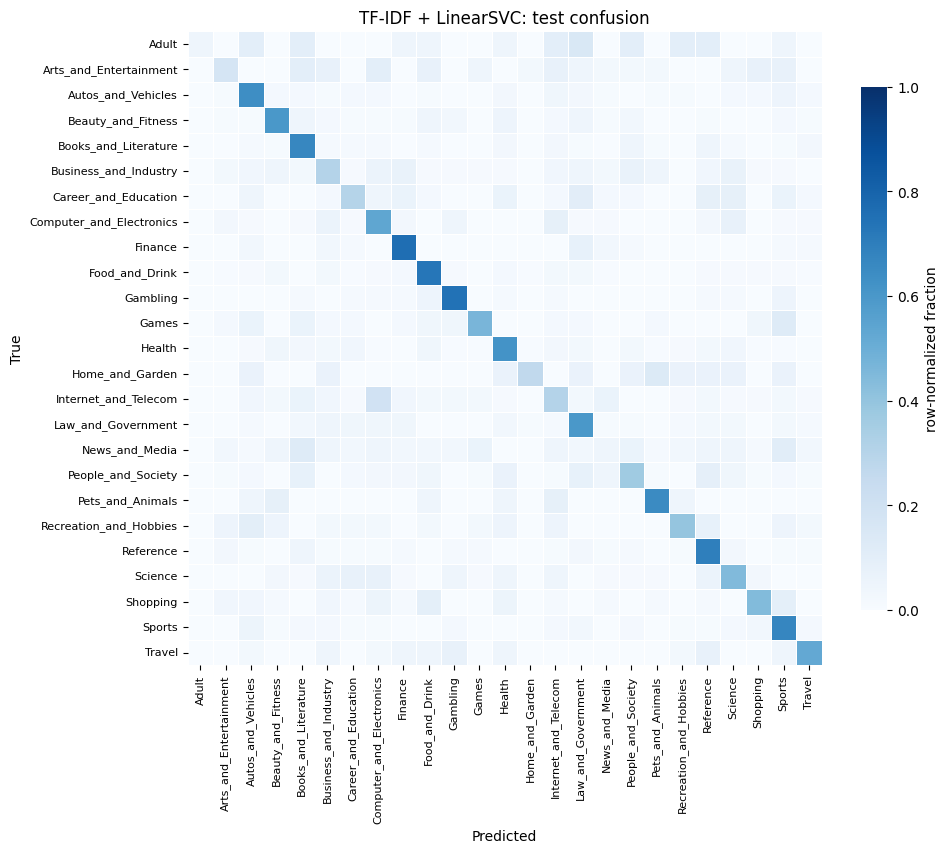

In [5]:
cm = confusion(yte, best.predict(Xte), len(label_names))
ax = plot_confusion_matrix(cm, label_names, f"TF-IDF + {best_name}: test confusion")
ax.figure.tight_layout()
ax.figure.savefig(FIG_DIR / "confusion_baseline.png", dpi=150)

## Takeaway

A tuned TF-IDF and linear model is a competitive baseline on this corpus. The
from-scratch DL model (notebook 03) may not beat it, and a result where it does
not is a valid finding given the corpus size.